In [1]:
import os
import sys

import warnings
warnings.filterwarnings('ignore')

project_root = 'c:/big20/git/big20-ML-project2-team3/SantanderCS'
# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Malgun Gothic'
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score
from utils.preprocessing import load_data, split_features_target, scale_data, data_split, remove_zero_columns2
from utils.user_utils import get_model_train_eval
from utils.feature_engineering import add_statistical_features,drop_highly_correlated_features

In [3]:
# 데이터 로딩 및 기본 전처리
train, test = load_data()
X_features, y_labels = split_features_target(train)
X_test = test.drop(columns=['ID'], axis=1)

In [4]:

# zero_count_rate 제거
X_features, X_test = remove_zero_columns2(X_features, X_test, 0.99)

# var3 처리
X_features['var3'] =  X_features['var3'].replace(-999999, 2)


Train Data Analysis (Threshold: 99.0% )
Train rows: 76,020, columns: 369
Test rows: 75,818, columns: 369

                                   Train Summary (zero_count 내림차순)                                    
                   ColumnName  na_Sum  nUnique          mode  modeFreq modeFreqRate  zero_count zero_count_rate_display
saldo_medio_var13_medio_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
                     ind_var2       0        1      0.000000     76020      100.00%       76020                 100.00%
        num_reemb_var33_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
    num_trasp_var17_out_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
    num_trasp_var33_out_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
              saldo_var2_ult1       0        1      0.000000     76020

In [ ]:


# # threshold 리스트
# thresholds = [0.85, 0.90, 0.95]

# print(f"zero_count_rate > 0.99 이상 제거 후 : \n")
# results = []
# drop_columns = {}    # threshold별 삭제 컬럼 기록용

# # 1. 상관계수 행렬 계산
# corr_matrix = X_features.corr().abs()
# upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# # np.triu: 행렬 위쪽 삼각형만 남김, np.ones: 1로 가득 찬 행렬 생성

# for th in thresholds:
    
#     # 2. threshold 이상인 컬럼 drop
#     to_drop = [column for column in upper.columns if any(upper[column] > th)]
#     drop_columns[th] = to_drop
#     X_reduced = X_features.drop(columns=to_drop)
#     X_test_reduced = X_test.drop(columns=to_drop)
    
#     # 3. 스케일링
#     X_train_scaled, X_test_scaled, scaler = scale_data(X_reduced, X_test_reduced)
    
#     # 4. 학습/검증 데이터 분리
#     X_train, X_val, y_train, y_val = data_split(X_reduced, y_labels)
    
#     model_name = 'LightGBM_99per_Corr_weight12'
#     # 모델 학습
#     lgbm_clf = LGBMClassifier(
#         random_state      = 0,
#         n_estimators      = 300,
#         num_leaves        = 32,        # 가지 수
#         min_child_samples = 24,
#         class_weight = {0:1, 1:2},
#         verbose           = -1
#     )
#     get_model_train_eval(lgbm_clf, model_name, X_train, X_val, y_train, y_val)
    
#     # 6. 성능 평가
#     y_pred = lgbm_clf.predict(X_val)
#     y_proba = lgbm_clf.predict_proba(X_val)[:,1]
    
#     auc = roc_auc_score(y_val, y_proba)
#     f1 = f1_score(y_val, y_pred)
#     recall = recall_score(y_val, y_pred)
    
#     results.append({
#         'threshold': th,
#         'dropped_features' : len(to_drop),
#         'AUC': auc,
#         'F1' : f1,
#         'Recall' : recall
#     })
# # 결과 출력
# results_df = pd.DataFrame(results)
# print(results_df)

zero_count_rate > 0.99 이상 제거 후 : 

✓ 모델 저장 완료: ../models\LightGBM_99per_Corr_weight12.pkl
  파일 크기: 1.01 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8342, 정확도: 0.9591, 정밀도: 0.2917, 재현율: 0.0233, F1: 0.0431
오차행렬:
[[14568    34]
 [  588    14]]
실행 시간: 2.398953676223755
✓ 모델 저장 완료: ../models\LightGBM_99per_Corr_weight12.pkl
  파일 크기: 1.01 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8291, 정확도: 0.9594, 정밀도: 0.3182, 재현율: 0.0233, F1: 0.0433
오차행렬:
[[14572    30]
 [  588    14]]
실행 시간: 1.051520824432373
✓ 모델 저장 완료: ../models\LightGBM_99per_Corr_weight12.pkl
  파일 크기: 1.02 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8337, 정확도: 0.9586, 정밀도: 0.2712, 재현율: 0.0266, F1: 0.0484
오차행렬:
[[14559    43]
 [  586    16]]
실행 시간: 1.2460520267486572
   threshold  dropped_features       AUC        F1    Recall
0       0.85                87  0.834167  0.043077  0.023256
1       0.90                73  0.829105  0.043344  0

In [ ]:


# # threshold 리스트
# thresholds = [0.85, 0.90, 0.95]

# print(f"zero_count_rate > 0.99 이상 제거 후 : \n")
# results = []
# drop_columns = {}    # threshold별 삭제 컬럼 기록용

# # 1. 상관계수 행렬 계산
# corr_matrix = X_features.corr().abs()
# upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# # np.triu: 행렬 위쪽 삼각형만 남김, np.ones: 1로 가득 찬 행렬 생성

# for th in thresholds:
    
#     # 2. threshold 이상인 컬럼 drop
#     to_drop = [column for column in upper.columns if any(upper[column] > th)]
#     drop_columns[th] = to_drop
#     X_reduced = X_features.drop(columns=to_drop)
#     X_test_reduced = X_test.drop(columns=to_drop)
    
#     # 3. 스케일링
#     X_train_scaled, X_test_scaled, scaler = scale_data(X_reduced, X_test_reduced)
    
#     # 4. 학습/검증 데이터 분리
#     X_train, X_val, y_train, y_val = data_split(X_reduced, y_labels)
    
#     model_name = 'LightGBM_99per_Corr_weight15'
#     # 모델 학습
#     lgbm_clf = LGBMClassifier(
#         random_state      = 0,  # 랜덤 시드 고정 → 동일 데이터면 같은 결과 재현
#         n_estimators      = 500, # 부스팅 반복 횟수(트리 개수), 많으면 학습 충분, 적으면 부족
#         num_leaves        = 32, # 하나 트리의 최대 잎사귀 수 → 트리 복잡도 조절          
#         min_child_samples = 18, # 리프 하나가 가져야 할 최소 샘플 수 → 과적합 방지, 양성 샘플 확보            
#         class_weight      = {0:1, 1:5}, # 불균형 데이터에서 양성 클래스(1)에 가중치 부여 → 재현율 향상
#         learning_rate     = 0.05, # 학습률 → 낮으면 안정적, 많으면 빠르지만 과적합 가능
#         subsample         = 0.8, # 행(row) 샘플링 비율 → 과적합 방지, 트리 다양성 증가
#         colsample_bytree  = 0.8, # 열(feature) 샘플링 비율 → 과적합 방지, 트리 다양성 증가
#         verbose           = -1 
#     )
    
#     get_model_train_eval(lgbm_clf, model_name, X_train, X_val, y_train, y_val)
    
#     # 6. 성능 평가
#     y_pred = lgbm_clf.predict(X_val)
#     y_proba = lgbm_clf.predict_proba(X_val)[:,1]
    
#     auc = roc_auc_score(y_val, y_proba)
#     f1 = f1_score(y_val, y_pred)
#     recall = recall_score(y_val, y_pred)
    
#     results.append({
#         'threshold': th,
#         'dropped_features' : len(to_drop),
#         'AUC': auc,
#         'F1' : f1,
#         'Recall' : recall
#     })
# # 결과 출력
# results_df = pd.DataFrame(results)
# print(results_df)

zero_count_rate > 0.99 이상 제거 후 : 

✓ 모델 저장 완료: ../models\LightGBM_99per_Corr_weight15.pkl
  파일 크기: 1.70 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8367, 정확도: 0.9290, 정밀도: 0.2436, 재현율: 0.3771, F1: 0.2960
오차행렬:
[[13897   705]
 [  375   227]]
실행 시간: 1.564016342163086
✓ 모델 저장 완료: ../models\LightGBM_99per_Corr_weight15.pkl
  파일 크기: 1.70 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8352, 정확도: 0.9280, 정밀도: 0.2364, 재현율: 0.3671, F1: 0.2876
오차행렬:
[[13888   714]
 [  381   221]]
실행 시간: 1.8955457210540771
✓ 모델 저장 완료: ../models\LightGBM_99per_Corr_weight15.pkl
  파일 크기: 1.70 MB
folder = c:\big20\git\big20-ML-project2-team3\SantanderCS\results
AUC: 0.8346, 정확도: 0.9278, 정밀도: 0.2342, 재현율: 0.3621, F1: 0.2844
오차행렬:
[[13889   713]
 [  384   218]]
실행 시간: 1.9110126495361328
   threshold  dropped_features       AUC        F1    Recall
0       0.85                87  0.836713  0.295958  0.377076
1       0.90                73  0.835151  0.287573  

In [7]:
# 1. 기본 피처 처리 + 통계 피처 생성
X_features, X_test = remove_zero_columns2(X_features, X_test, 0.99)
X_features['var3'] = X_features['var3'].replace(-999999, 2)

# 통계 피처 추가
X_features = add_statistical_features(X_features)
X_test = add_statistical_features(X_test)

# 2. threshold 리스트
thresholds = [0.85, 0.90, 0.95]

results = []
drop_columns = {}

for th in thresholds:
    
    # 상관계수 기반 컬럼 제거
    X_reduced, to_drop = drop_highly_correlated_features(X_features, threshold=th)
    drop_columns[th] = to_drop
    X_test_reduced = X_test.drop(columns=to_drop)
    
    # 스케일링
    X_train_scaled, X_test_scaled, scaler = scale_data(X_reduced, X_test_reduced)
    
    # 학습/검증 데이터 분리
    X_train, X_val, y_train, y_val = data_split(X_reduced, y_labels)
    
    # 모델 정의
    model_name = f'LightGBM_99per_Corr_weight15_th{th}'
    lgbm_clf = LGBMClassifier(
        random_state      = 0,
        n_estimators      = 500,
        num_leaves        = 32,
        min_child_samples = 18,
        class_weight      = {0:1, 1:5},
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        verbose           = -1
    )
    
    # 학습 + 평가
    get_model_train_eval(lgbm_clf, model_name, X_train, X_val, y_train, y_val)
    
    # 성능 평가
    y_pred = lgbm_clf.predict(X_val)
    y_proba = lgbm_clf.predict_proba(X_val)[:,1]
    results.append({
        'threshold': th,
        'dropped_features' : len(to_drop),
        'AUC': roc_auc_score(y_val, y_proba),
        'F1' : f1_score(y_val, y_pred),
        'Recall' : recall_score(y_val, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)



Train Data Analysis (Threshold: 99.0% )
Train rows: 76,020, columns: 149
Test rows: 75,818, columns: 149

                                   Train Summary (zero_count 내림차순)                                    
                   ColumnName  na_Sum  nUnique          mode  modeFreq modeFreqRate  zero_count zero_count_rate_display
            ind_var13_largo_0       0        2      0.000000     75247       98.98%       75247                  98.98%
            num_var13_largo_0       0        7      0.000000     75247       98.98%       75247                  98.98%
                  num_var40_0       0        3      0.000000     75152       98.86%       75152                  98.86%
                  ind_var40_0       0        2      0.000000     75152       98.86%       75152                  98.86%
                        var21       0       24      0.000000     75152       98.86%       75152                  98.86%
                   num_var1_0       0        3      0.000000     75149

In [8]:
# threshold별 삭제된 컬럼 집합 (drop_columns dict에서 가져오기)
set_085 = set(drop_columns[0.85])
set_090 = set(drop_columns[0.90])
set_095 = set(drop_columns[0.95])

# 고유하게 삭제된 컬럼
unique_085 = set_085 - set_090 - set_095
unique_090 = set_090 - set_085 - set_095
unique_095 = set_095 - set_085 - set_090

print("0.85에서만 삭제된:", unique_085)
print("0.90에서만 삭제된:", unique_090)
print("0.95에서만 삭제된:", unique_095)

# 공통 삭제된 컬럼
common_all = set_085 & set_090 & set_095
print("모든 threshold에서 공통 삭제된:", common_all)

# unique/공통 컬럼 비교용 DataFrame
tmpdf = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in drop_columns.items()]))
tmpdf.to_csv("../data/99per_drop_columns.xls", index=False)


0.85에서만 삭제된: {'num_var39_0', 'ind_var10_ult1', 'num_var12_0', 'num_var30', 'num_var42', 'saldo_var13', 'ind_var8_0', 'ind_var24_0', 'imp_op_var39_comer_ult3', 'imp_op_var41_ult1', 'saldo_medio_var13_corto_hace2', 'saldo_medio_var12_hace2', 'num_var45_ult1', 'num_var26_0'}
0.90에서만 삭제된: set()
0.95에서만 삭제된: set()
모든 threshold에서 공통 삭제된: {'ind_var26_cte', 'saldo_var25', 'num_var8', 'ind_var13_corto', 'num_var26', 'imp_op_var39_efect_ult1', 'num_op_var39_ult3', 'saldo_medio_var13_corto_ult1', 'ind_var25', 'saldo_medio_var12_ult1', 'num_op_var41_comer_ult3', 'num_op_var39_hace2', 'num_var24_0', 'num_var5', 'saldo_medio_var13_corto_ult3', 'ind_var9_cte_ult1', 'delta_num_aport_var13_1y3', 'num_meses_var13_corto_ult3', 'imp_op_var41_comer_ult3', 'num_meses_var12_ult3', 'ind_var13', 'num_var25_0', 'ind_var41_0', 'num_var1_0', 'num_op_var41_comer_ult1', 'num_op_var39_hace3', 'num_op_var39_ult1', 'num_var40_0', 'num_op_var39_efect_ult3', 'ind_var40_0', 'imp_op_var39_efect_ult3', 'saldo_var42', 'ind_

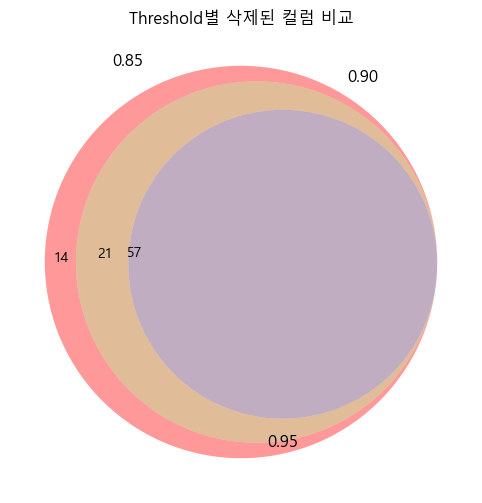

In [9]:
# Venn Diagram 그리기
# pip install matplotlib_venn
from matplotlib_venn import venn3

plt.figure(figsize=(8,6))
venn3([set_085, set_090, set_095], set_labels=('0.85','0.90','0.95'))
plt.title('Threshold별 삭제된 컬럼 비교')
plt.show()

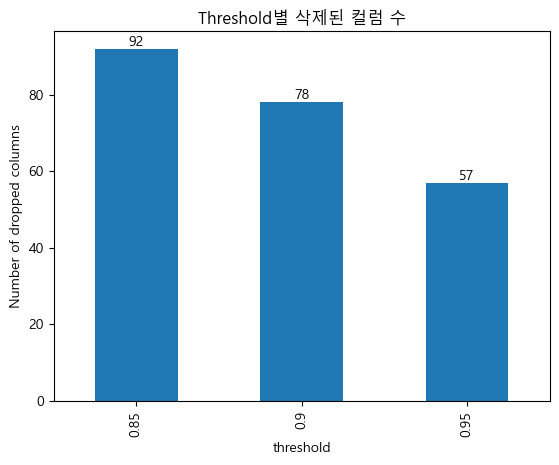

In [10]:
import matplotlib.pyplot as plt

ax = results_df.plot(
    x="threshold", 
    y="dropped_features", 
    kind="bar", 
    legend=False
)

plt.title("Threshold별 삭제된 컬럼 수")
plt.ylabel("Number of dropped columns")

# 막대 위에 수치 레이블 추가
ax.bar_label(ax.containers[0])

plt.show()


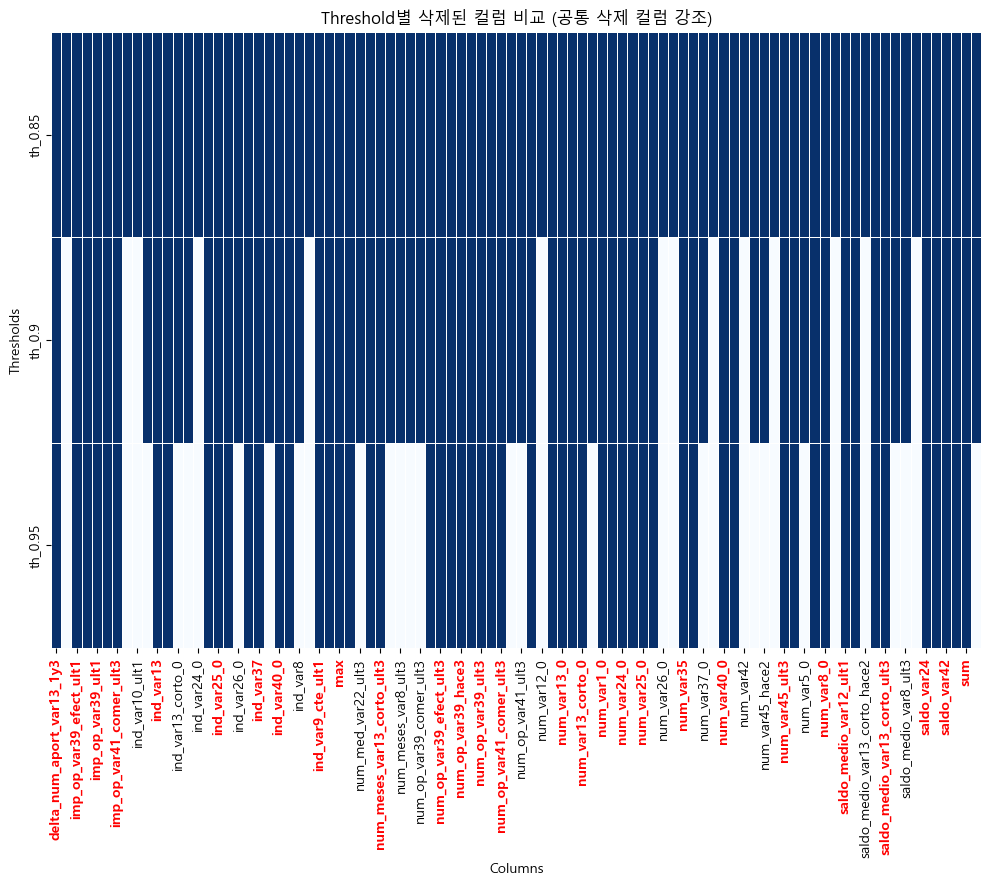

In [11]:
# 존재 여부 매트릭스 생성 (앞에서 만든 comparison_matrix)
# drop_columns 딕셔너리 안에 있는 모든 컬럼을 합쳐서 집합 생성
all_dropped = set()
for cols in drop_columns.values():
    all_dropped.update(cols)
    
comparison_matrix = pd.DataFrame(index=sorted(all_dropped))
for th, cols in drop_columns.items():
    comparison_matrix[f"th_{th}"] = comparison_matrix.index.isin(cols)
comparison_matrix = comparison_matrix.astype(int)

# 공통으로 삭제된 컬럼
common_all = set(drop_columns[0.85]) & set(drop_columns[0.90]) & set(drop_columns[0.95])

# heatmap 그리기
plt.figure(figsize=(12,8))
ax = sns.heatmap(comparison_matrix.T, cmap="Blues", cbar=False, linewidths=0.5)

# 공통 삭제된 컬럼에 대해 x축 라벨 색상 변경
for label in ax.get_xticklabels():
    if label.get_text() in common_all:
        label.set_color("red")   # 공통 삭제된 컬럼은 빨간색
        label.set_fontweight("bold")

plt.title("Threshold별 삭제된 컬럼 비교 (공통 삭제 컬럼 강조)")
plt.xlabel("Columns")
plt.ylabel("Thresholds")
plt.show()